**Task 1: Algorithm Explanation**


**What is the algorithm?**


Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value by finding the relationship between input features and the target variable.

Polynomial Regression is an extension of Linear Regression that can model non-linear relationships by adding polynomial terms to the features.

**How does the algorithm work?**


for Linear Regression it finds the best-fit line that minimizes the difference between the predicted values and the actual values. The model learns this relationship from the training data and uses it to make predictions.

for Polynomial Regression it should be used when the relationship between the features and the target is not linear.

**When should this algorithm be used?**

for Linear Regression It should be used when the target variable is continuous and there is a linear relationship between the features and the target.

for Polynomial Regression it should be used when the relationship between the features and the target is non-linear, meaning a straight line cannot accurately fit the data.

**-Advantages:**
Simple and easy to understand,
Fast to train,
Easy to interpret the results.

**-Limitations:**
Assumes a linear relationship,
Sensitive to outliers,
May not perform well on complex datasets.

In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [193]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noordeen/insurance-premium-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance-premium-prediction' dataset.
Path to dataset files: /kaggle/input/insurance-premium-prediction


**Task 2: Exploratory Data Analysis (EDA)**

- Dataset Overview
- Missing Values
- Histograms
- Scatter Plots
- Correlation Heatmap

In [194]:
df = pd.read_csv("insurance.csv")

In [195]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [196]:
df.shape

(1338, 7)

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [198]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


The dataset contains medical information about insurance
customers. The target variable is expenses, which represents medical insurance costs.

In [199]:
X = df.drop("expenses", axis=1)
y = df["expenses"]

In [200]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


The dataset has no missing values. All columns are complete and ready for analysis.

EXPENSES

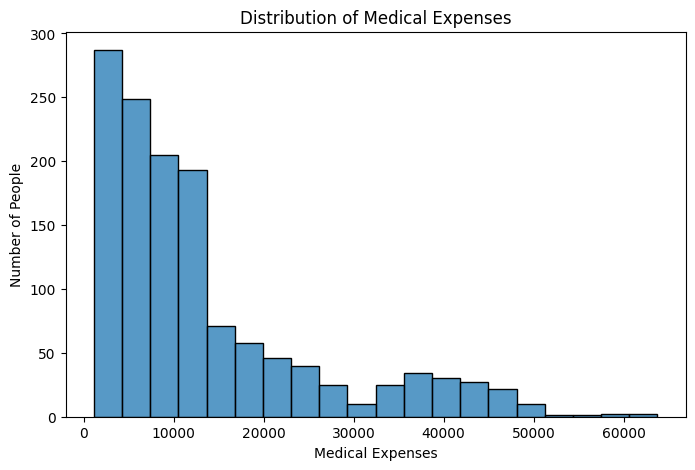

In [201]:
plt.figure(figsize=(8,5))
sns.histplot(df["expenses"], bins=20)

plt.title("Distribution of Medical Expenses")
plt.xlabel("Medical Expenses")
plt.ylabel("Number of People")

plt.show()

INSIGHT: Most people have low medical expenses, while only a small number have very high expenses. This means the distribution is right-skewed.

Box Plot of Medical Expenses

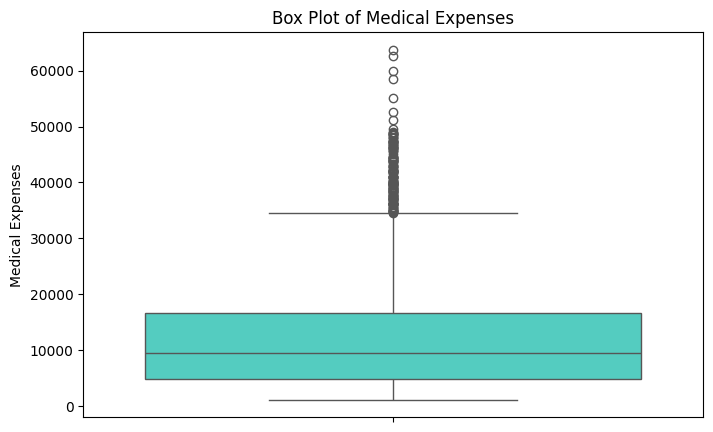

In [202]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["expenses"], data=df, color="turquoise")

plt.title("Box Plot of Medical Expenses")
plt.ylabel("Medical Expenses")

plt.show()

INSIGHT: The box plot shows several outliers in medical expenses. This indicates that a small number of people have much higher medical expenses than the rest of the dataset

AGE

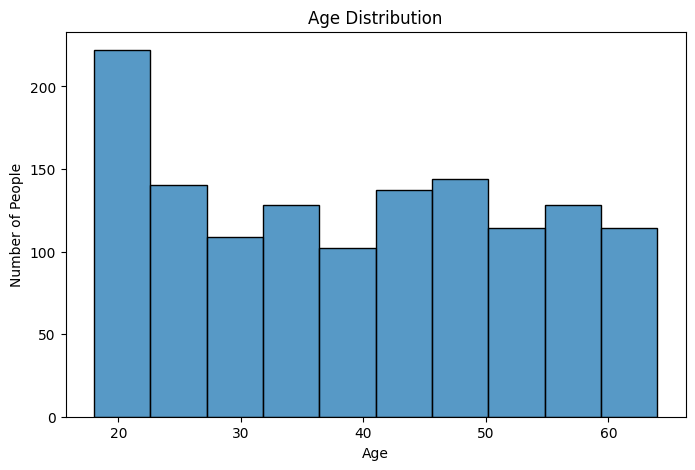

In [203]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")

plt.show()

INSIGHT: The ages in the dataset range from 18 to 64 years. Most age groups are well represented, showing a good variety of participants.

BMI

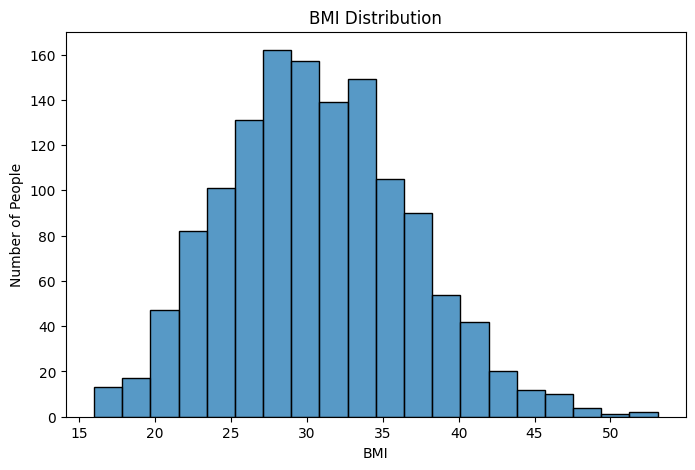

In [204]:
plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of People")

plt.show()

#BMI = body weight (in kilograms) divided by the square of their height (in meters).

INSIGHT: Most people have a BMI between 25 and 35, histogram shows how BMI values are distributed among the participants. It helps us understand the most common BMI range in the dataset.

CHILDREN

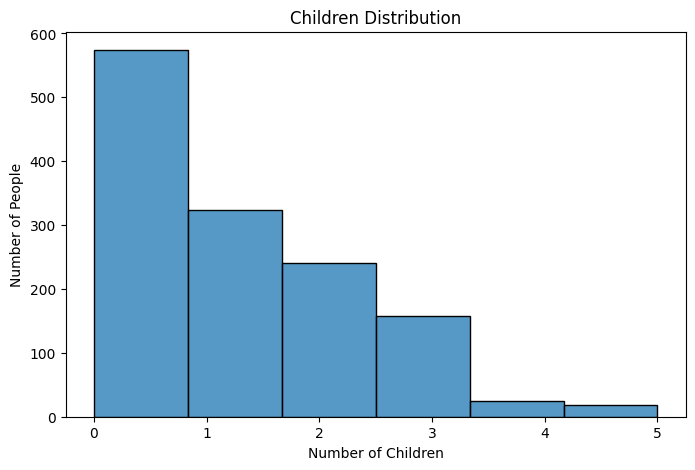

In [205]:
plt.figure(figsize=(8,5))
sns.histplot(df["children"], bins=6)

plt.title("Children Distribution")
plt.xlabel("Number of Children")
plt.ylabel("Number of People")

plt.show()

INSIGHT: Most people have no children, while fewer people have one or more children.

AGE VS EXPENSSES

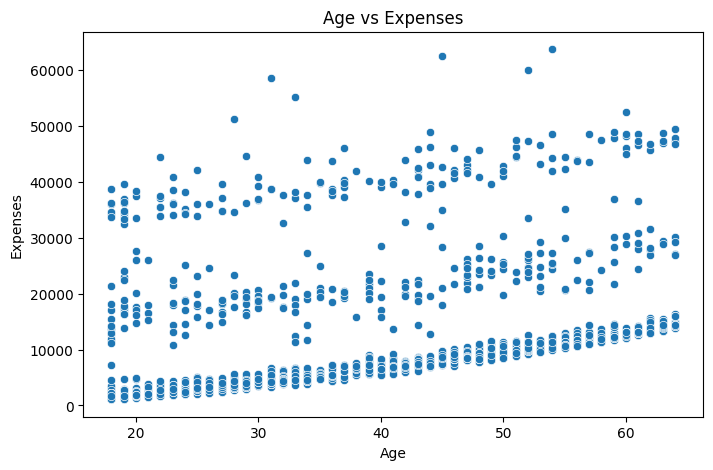

In [206]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="expenses", data=df)

plt.title("Age vs Expenses")
plt.xlabel("Age")
plt.ylabel("Expenses")

plt.show()

INSIGHT: There is a positive relationship BUT NOT STRONG between age and expenses. Older people tend to have higher medical expenses.

BMI VS EXPENSES

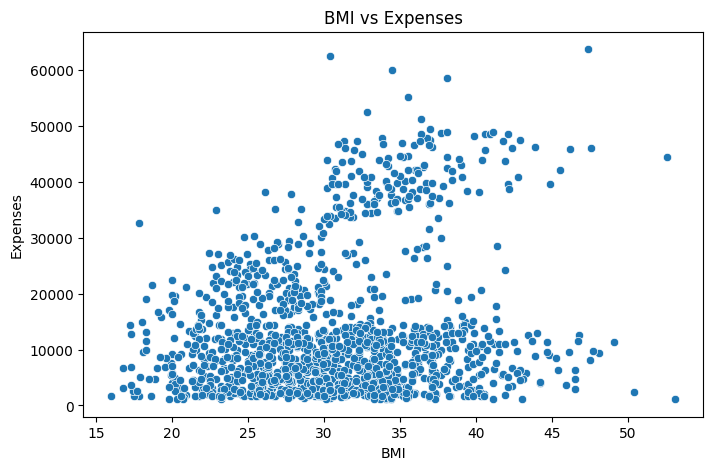

In [207]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi", y="expenses", data=df)

plt.title("BMI vs Expenses")
plt.xlabel("BMI")
plt.ylabel("Expenses")

plt.show()

INSIGHT: People with higher BMI THAN 30 may have higher medical expenses, but the relationship is not very strong.

BMI CATEGORY VS MEDICAL EXPENSES

/tmp/ipykernel_2709/4193317668.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


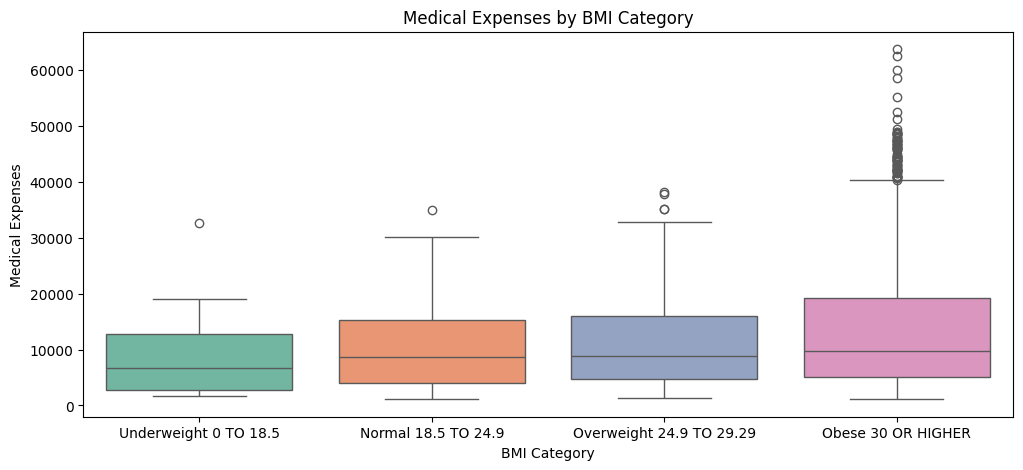

In [208]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 24.9, 29.29, 100],
    labels=["Underweight 0 TO 18.5", "Normal 18.5 TO 24.9", "Overweight 24.9 TO 29.29", "Obese 30 OR HIGHER"]
)

#0 TO 18.5 = UNDERWEIGHT
#18.5 TO 24.9 = NORMAL
#24.9 TO 29.29 = OVERWEIGHT
#29.29 TO 100 = OBESE
plt.figure(figsize=(12,5))

sns.boxplot(
    x="bmi_category",
    y="expenses",
    data=df,
    palette="Set2"
)

plt.title("Medical Expenses by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Medical Expenses")

plt.show()

Medical expenses generally increase as BMI increases. The Obese group has the highest expenses and the largest number of outliers

BOX PLOT FOR SMOKER VS EXPENSES

/tmp/ipykernel_2709/2858836684.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


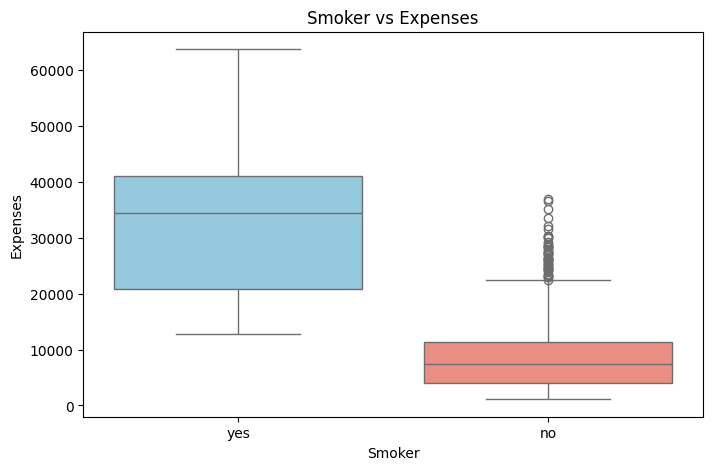

In [209]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="smoker",
    y="expenses",
    data=df,
    palette=["skyblue","salmon"]
)
plt.title("Smoker vs Expenses")
plt.xlabel("Smoker")
plt.ylabel("Expenses")

plt.show()


INSIGHT: Smokers generally have higher medical expenses than non-smokers. The box plot also shows several outliers among smokers.

SMOKERS AND NON SMOKERS

/tmp/ipykernel_2709/4051609649.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="smoker", data=df, palette="Set2")


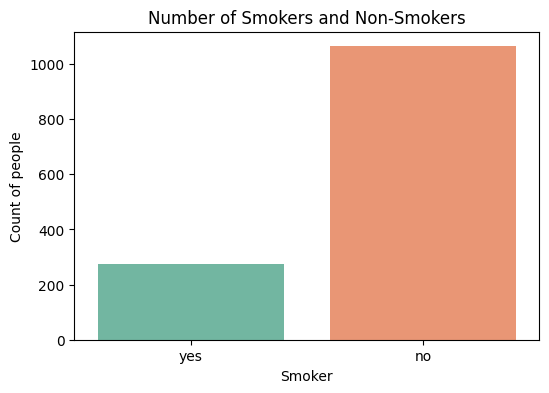

In [210]:
plt.figure(figsize=(6,4))

sns.countplot(x="smoker", data=df, palette="Set2")

plt.title("Number of Smokers and Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Count of people")

plt.show()

Most individuals in the dataset are non-smokers, while a smaller amount of people are smokers

CORRELATION HEATMAP

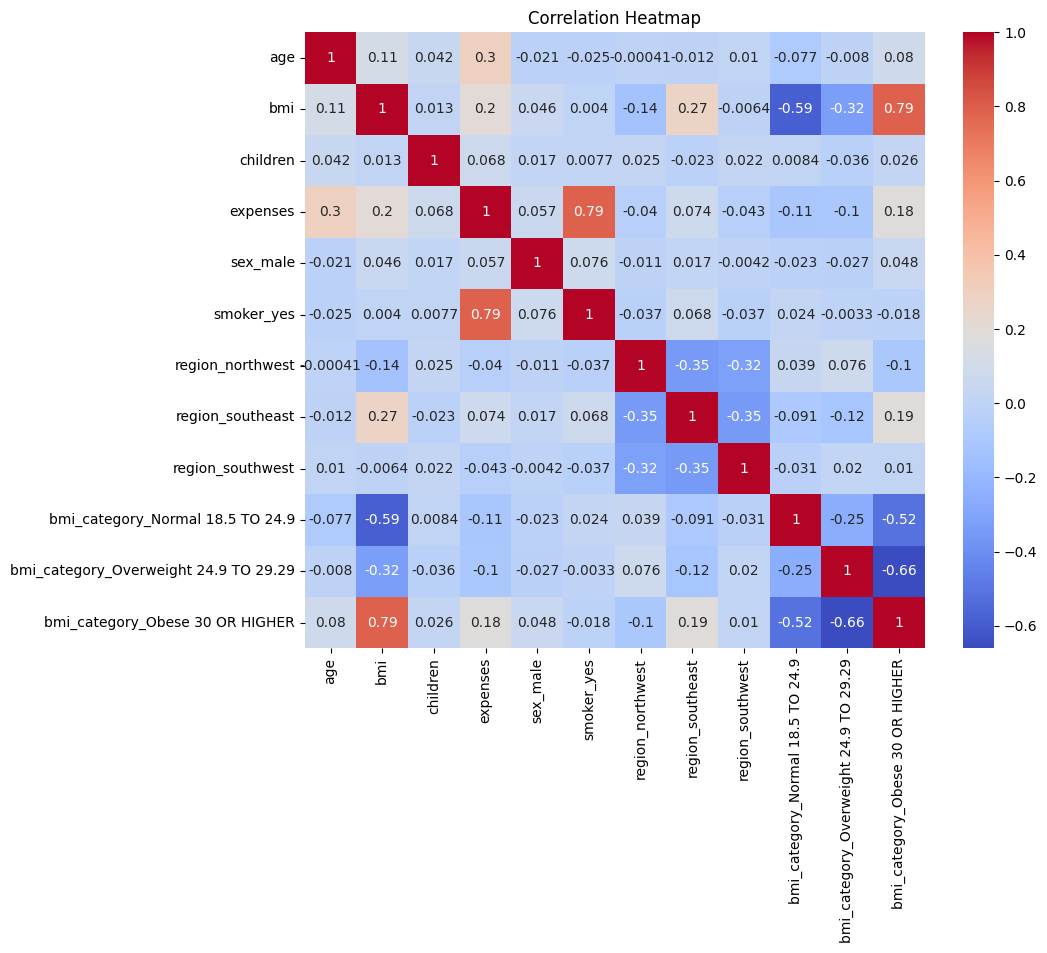

In [211]:
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
#Categorical variables were encoded into numerical values before generating the correlation heatmap, otherwise it wont wrok

plt.title("Correlation Heatmap")
plt.show()

INSIGHT: The heatmap shows the correlation between variables. Smoking has the strongest positive relationship with medical expenses, while age and BMI have moderate positive correlations.

---

# - Data Preprocessing

In [212]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

## -Checking missing Values :

In [213]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0
bmi_category,0


In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   age           1338 non-null   int64   
 1   sex           1338 non-null   object  
 2   bmi           1338 non-null   float64 
 3   children      1338 non-null   int64   
 4   smoker        1338 non-null   object  
 5   region        1338 non-null   object  
 6   expenses      1338 non-null   float64 
 7   bmi_category  1338 non-null   category
dtypes: category(1), float64(2), int64(2), object(3)
memory usage: 74.8+ KB


- The dataset has no missing values
- Each column of the dataset has the right datatype

---

### - Encoding categorical variables

#### - Using lable  encoder (0,1) for the sex / smoker columns

In [215]:
#using label encoder
le_sex = LabelEncoder()
le_smoker= LabelEncoder()

df['sex']=le_sex.fit_transform(df['sex'])
df['smoker'] = le_smoker.fit_transform(df['smoker'])


#### Using One-hot encoding for region column its unordered,becuse the region column has more than 2 categories

In [216]:
df = pd.get_dummies(df, columns=["region"], drop_first=False)

df.head()

,age,sex,bmi,children,smoker,expenses,bmi_category,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.9,0,1,16884.92,Overweight 24.9 TO 29.29,False,False,False,True
1,18,1,33.8,1,0,1725.55,Obese 30 OR HIGHER,False,False,True,False
2,28,1,33.0,3,0,4449.46,Obese 30 OR HIGHER,False,False,True,False
3,33,1,22.7,0,0,21984.47,Normal 18.5 TO 24.9,False,True,False,False
4,32,1,28.9,0,0,3866.86,Overweight 24.9 TO 29.29,False,True,False,False


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               1338 non-null   int64   
 1   sex               1338 non-null   int64   
 2   bmi               1338 non-null   float64 
 3   children          1338 non-null   int64   
 4   smoker            1338 non-null   int64   
 5   expenses          1338 non-null   float64 
 6   bmi_category      1338 non-null   category
 7   region_northeast  1338 non-null   bool    
 8   region_northwest  1338 non-null   bool    
 9   region_southeast  1338 non-null   bool    
 10  region_southwest  1338 non-null   bool    
dtypes: bool(4), category(1), float64(2), int64(4)
memory usage: 69.6 KB


### - Splitting the data into Train/Split

In [236]:
X = df.drop(columns=["expenses" ,'bmi_category'])
y = df[["expenses"]]


X_train, X_test , y_train , y_test = train_test_split(X,y , test_size=0.2 , random_state=42)

X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.9,0,1,False,False,False,True
1,18,1,33.8,1,0,False,False,True,False
2,28,1,33.0,3,0,False,False,True,False
3,33,1,22.7,0,0,False,True,False,False
4,32,1,28.9,0,0,False,True,False,False


###- Scaling the feature variable

In [237]:
X_train.dtypes

,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
region_northeast,bool
region_northwest,bool
region_southeast,bool
region_southwest,bool


In [238]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
560,0.472227,-1.024602,-1.748572,0.734336,-0.508747,-0.576631,1.783168,-0.599661,-0.572314
1285,0.543313,-1.024602,-1.036704,-0.911192,-0.508747,1.734212,-0.560800,-0.599661,-0.572314
1142,0.898745,-1.024602,-0.937373,-0.911192,-0.508747,-0.576631,-0.560800,1.667609,-0.572314
969,-0.025379,-1.024602,0.618804,3.202629,-0.508747,-0.576631,-0.560800,1.667609,-0.572314
486,1.040918,-1.024602,-1.500246,1.557100,-0.508747,-0.576631,1.783168,-0.599661,-0.572314


###- Scaling the target variable

In [239]:
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

- We scaled both features and target for consistency and numerical stability across Linear and Polynomial Regression — predictions are inverse-transformed back to dollars afterward so RMSE stays meaningful.
---

### -Model Implementation

In [240]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [241]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression())

poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_test)

---

### - Model Evalouation

In [243]:
mae_linear = mean_absolute_error(y_test, y_pred)
mse_linear = mean_squared_error(y_test, y_pred)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred)

print(f"Linear Regression MAE: {mae_linear:.2f}")
print(f"Linear Regression MSE: {mse_linear:.2f}")
print(f"Linear Regression RMSE: {rmse_linear:.2f}")
print(f"Linear Regression R2 Score: {r2_linear:.2f}")

Linear Regression MAE: 4181.56
Linear Regression MSE: 33600065.36
Linear Regression RMSE: 5796.56
Linear Regression R2 Score: 0.78


In [244]:
mae_poly = mean_absolute_error(y_test, poly_pred)
mse_poly = mean_squared_error(y_test, poly_pred)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, poly_pred)

print(f"Polynomial Regression MAE: {mae_poly:.2f}")
print(f"Polynomial Regression MSE: {mse_poly:.2f}")
print(f"Polynomial Regression RMSE: {rmse_poly:.2f}")
print(f"Polynomial Regression R2 Score: {r2_poly:.2f}")

Polynomial Regression MAE: 2729.98
Polynomial Regression MSE: 20701911.26
Polynomial Regression RMSE: 4549.94
Polynomial Regression R2 Score: 0.87


**Model Evaluation & Interpretation**

Based on the evaluation metrics and the visualization above, here is the interpretation of our models' performance:

- R² Score (Accuracy): - The Linear Regression model has an  R2  score of 0.78, meaning it can explain 78% of the variance in medical insurance expenses using the given features.

- The Polynomial Regression (Degree 2) significantly improved the performance, raising the  R2  score to 0.87 (explaining 87% of the variance). This proves that the relationship between features like (Age, BMI) and Insurance Charges is non-linear.

- Mean Absolute Error (MAE):
For Linear Regression, the MAE is around 4,181, meaning our predictions are, on average, off by $4,181 from the actual cost.
Polynomial Regression reduced this error to 2,729, which makes the model much more reliable and closer to the actual values.

- MSE & RMSE:
The Root Mean Squared Error (RMSE) dropped from 5,796 (Linear) to 4,550 (Polynomial). Since RMSE penalizes larger errors, this reduction shows that the Polynomial model handles unusual high-cost insurance cases (outliers) much better than the standard linear model.

---

##- Final Summary

In [252]:
summary = pd.DataFrame({
    'Metric ': [
        'Mean Absolute Error (MAE)',
        'Mean Squared Error (MSE)',
        'Root Mean Squared Error (RMSE)',
        'R² Score (Accuracy)'
    ],
    'Linear Regression (Base)': [mae_linear, mse_linear, rmse_linear, r2_linear],
    'Polynomial Regression (Bonus)': [mae_poly, mse_poly, rmse_poly, r2_poly]
})

print("======= MODEL COMPARISON =======")
print(summary.to_string(index=False))

======= MODEL COMPARISON =======
                       Metric   Linear Regression (Base)  Polynomial Regression (Bonus)
     Mean Absolute Error (MAE)              4.181562e+03                   2.729979e+03
      Mean Squared Error (MSE)              3.360007e+07                   2.070191e+07
Root Mean Squared Error (RMSE)              5.796556e+03                   4.549935e+03
           R² Score (Accuracy)              7.835727e-01                   8.666533e-01


---

## Comarision between Linear Regression & Polynomial Regression

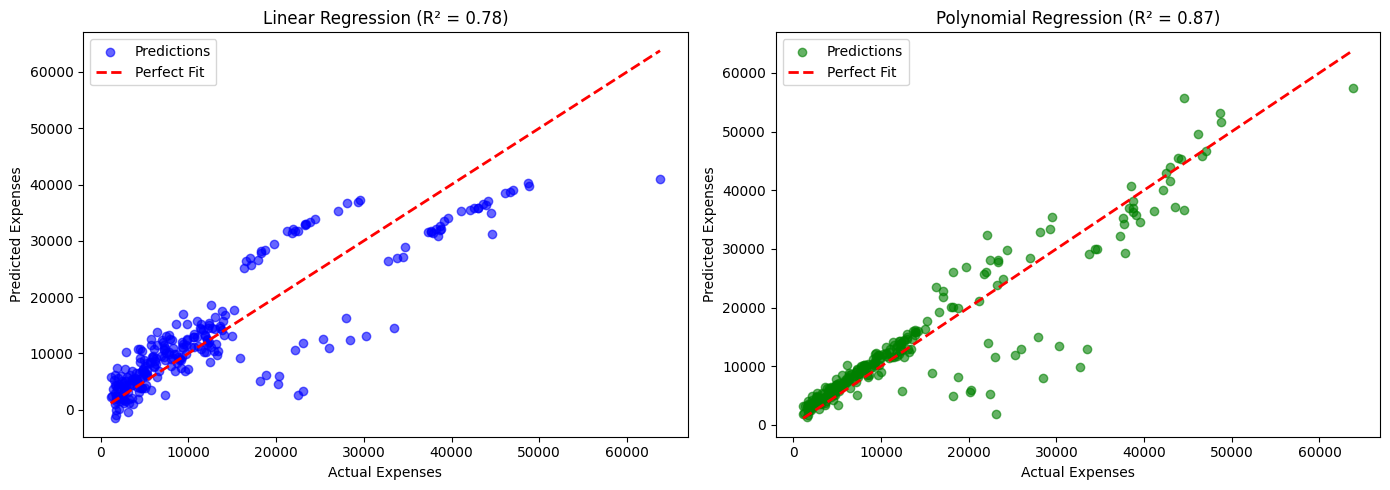

In [253]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Linear Regression (R² = 0.78)')
plt.xlabel('Actual Expenses')
plt.ylabel('Predicted Expenses')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, poly_pred, alpha=0.6, color='green', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Polynomial Regression (R² = 0.87)')
plt.xlabel('Actual Expenses')
plt.ylabel('Predicted Expenses')
plt.legend()

plt.tight_layout()
plt.show()


# -Project Key Insights  :


- Smokers pay the most: smoking status is the strongest driver of medical expenses in this dataset, far outweighing other factors.

- Age and BMI matter, but modestly: both show a positive but weak-to-moderate correlation with expenses — costs tend to rise somewhat with age and with BMI, especially once BMI passes 30.

- Costs are skewed by a small high-cost minority: most people have low expenses, but a small group (concentrated among smokers and the obese) drives the right-skew and most of the outliers seen in the box plots.

- Polynomial Regression outperformed Linear Regression on every metric: R² rose from 0.78 to 0.87, showing it captures significantly more of the variance in expenses.

- The non-linear model confirms the underlying relationship isn't linear: since adding a squared term (Degree 2) improved fit this much, features like age and BMI relate to expenses in a curved rather than straight-line way.

- Errors dropped meaningfully with the polynomial model: MAE fell from $ 4,181 to  $ 2,729 and RMSE from $5,796 to  $4,550, meaning predictions are both more accurate on average and better at handling the high-cost outlier cases.